# Various Data Tests

In [39]:
import pandas as pd
import numpy as np
import random
import os
import torch
import faiss
import json
import re
import shutil
import random
from tqdm import tqdm
from torch import Tensor
from dotenv import load_dotenv
from huggingface_hub import login
from torch.utils.data import DataLoader
import torch.nn.functional as F
from beir.datasets.data_loader import GenericDataLoader
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, logging, AutoModel, AutoModelForCausalLM
logging.set_verbosity_error()
import matplotlib.pyplot as plt

In [4]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco"
train_corpus, train_queries, train_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')
test_corpus, test_queries, test_qrels = GenericDataLoader(data_folder=data_dir).load(split='dev')

100%|██████████| 8841823/8841823 [01:17<00:00, 114591.28it/s]


In [5]:
test_q = [(q_id, query) for q_id, query in test_queries.items()]
train_q = [(q_id, query) for q_id, query in train_queries.items()]

# Query Cosine Similarity

In [78]:
df = pd.read_json("/work/mbouthil/MMATH-CM-Research-Project/RAG/test_results/sim_ids.jsonl", lines=True)
df.head()

""


# Plotting query distributions

In [12]:
from collections import Counter
import spacy
nlp = spacy.load("en_core_web_sm")

In [28]:
all_queries = list(train_queries.values()) + list(test_queries.values())

words = set([word
        for query in all_queries
        for word in query.split()])

stop_words = set([stop_word for stop_word in words if stop_word in nlp.Defaults.stop_words])

In [56]:
def tokenize_corpus(corpus, stop_words=None):
    tokens = []
    for doc in corpus:
        for word in doc.split():
            if stop_words and word in stop_words:
                continue
            tokens.append(word.lower())
    return tokens

def relative_freq(tokens):
    counts = Counter(tokens)
    total = sum(counts.values())
    return {w:c/total for w,c in counts.items()}

In [65]:
train_tokens = tokenize_corpus(list(train_queries.values()), stop_words=stop_words)
test_tokens = tokenize_corpus(list(test_queries.values()), stop_words=stop_words)

train_dist = relative_freq(train_tokens)
test_dist = relative_freq(test_tokens)

vocab = sorted(set(train_dist.keys()).union(test_dist.keys()))

In [66]:
from scipy.spatial.distance import jensenshannon

train_vec = np.array([train_dist.get(w,0) for w in vocab])
test_vec = np.array([test_dist.get(w,0) for w in vocab])

js = jensenshannon(train_vec, test_vec)
print("JS divergence:", js)

JS divergence: 0.4231946249684523


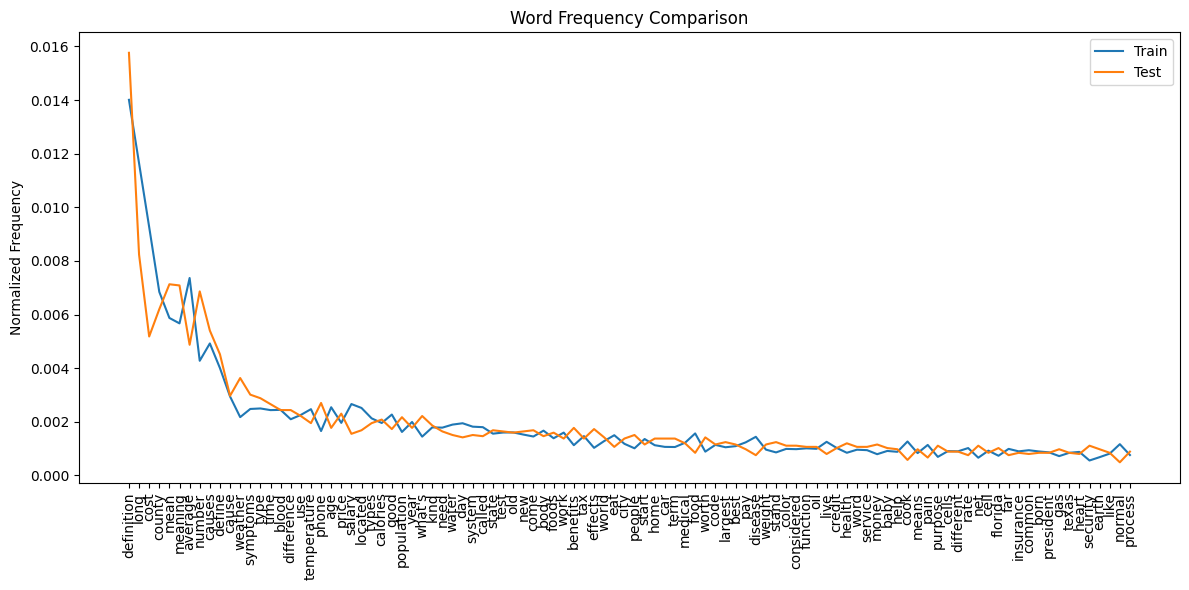

In [71]:
order = np.argsort(train_vec + test_vec)[::-1]
# order = np.argsort(train_vec)[::-1]

K = 100
vocab_sorted = [vocab[i] for i in order[:K]]
train_sorted = train_vec[order][:K]
test_sorted  = test_vec[order][:K]

plt.figure(figsize=(12,6))
x = np.arange(len(vocab_sorted))

plt.plot(x, train_sorted, label="Train")
plt.plot(x, test_sorted, label="Test")

plt.xticks(x, vocab_sorted, rotation=90)
plt.ylabel("Normalized Frequency")
plt.title("Word Frequency Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
i=0

for query in test_queries.values():
    if 'definition' in query.lower():
        i+=1

print(i)

362


# Various Data Inspection

In [36]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco_synq_final"
synq_corpus, synq_queries, synq_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')

100%|██████████| 8841823/8841823 [01:18<00:00, 113321.17it/s]


In [37]:
print(len(synq_queries))
print(len(train_queries))
print(len(train_queries)-len(synq_queries))

1005878
502939
-502939
